In [21]:
# If import still fails, install the local package in editable mode
# and restart the kernel (may require internet if dependencies are missing).
# Uncomment and run the line below:
# %pip install -e ..


In [22]:
# Restart kernel to reload fixed modules
import sys
for module_name in list(sys.modules.keys()):
    if 'stochlib' in module_name:
        del sys.modules[module_name]

# Ensure repo src is importable in this kernel
import os
# Notebook cwd is typically the examples/ folder; use parent as repo root
repo_root = os.path.dirname(os.getcwd())
src_path = os.path.join(repo_root, "src")
if os.path.isdir(src_path) and src_path not in sys.path:
    sys.path.insert(0, src_path)

try:
    import stochlib
    print("Imported stochlib OK from:", stochlib.__file__)
except ModuleNotFoundError:
    print("stochlib not found. From this notebook, install with '%pip install -e ..' then restart the kernel.")
    raise


Imported stochlib OK from: /Users/jasperaden/Documents/Stochastic Simulations/Stochastic-Simulations/src/stochlib/__init__.py


> Note: If `stochlib` is not found when running this notebook, the code below adds the repository's `src/` folder to `sys.path` for imports. Alternatively, install the package in editable mode with `uv pip install -e .` and restart the kernel.

# FP vs SDE Paths: Comparison Workflow

This notebook demonstrates how to:
- Define a 1D grid and FP configurations (`VelocitiesConfig`, `DiffusionConfig`)
- Convert FP configs to SDE drift/diffusion using `fp_to_sde_drift` and `fp_to_sde_diffusion`
- Simulate paths with `PathSimulator` in `absorb` and `reflect` boundary modes
- Build a histogram of path positions and compare to an analytic FP distribution
- Compare moments (mean and variance) and visualize trajectories and distributions

In [23]:
# Imports
import numpy as np
import matplotlib.pyplot as plt

from stochlib.setup import Grid, VelocitiesConfig, DiffusionConfig
from stochlib.sde.bridge import fp_to_sde_drift, fp_to_sde_diffusion, grid_bounds_from_grid
from stochlib.sde.solver import PathSimulator
from stochlib.sde.diagnostic import PathDiagnostics
from stochlib.sde.comparison import paths_to_histogram, compare_distributions, compare_moments


In [24]:
# Setup grid and FP configurations

# 1D grid in [0, 10]
grid = Grid(x_start=0.0, x_end=10.0, num_points_x=201)

# Zero drift (pure diffusion)
velocities = VelocitiesConfig(grid, mu_x=0.0)

# Constant diffusion D = 0.1
diffusions = DiffusionConfig(grid, axes=['x'], constants={'x': 0.1})

# Convert to SDE drift/diffusion
mu = fp_to_sde_drift(velocities, grid)
sigma = fp_to_sde_diffusion(diffusions, grid)

# Extract domain bounds for boundary handling
lower, upper = grid_bounds_from_grid(grid)


In [25]:
# Analytic FP distribution at final time (pure diffusion)

def gaussian_pdf(x, mean, sigma):
    return np.exp(-(x - mean)**2 / (2.0 * sigma**2)) / (np.sqrt(2.0 * np.pi) * sigma)

x0 = 5.0  # initial center
sigma0 = 0.5
D = 0.1
t_array = np.linspace(0.0, 1.0, 51)  # 50 steps to t=1

# Effective sigma at final time for pure diffusion: sigma^2(t) = sigma0^2 + 2*D*t
sigma_t = np.sqrt(sigma0**2 + 2.0 * D * t_array[-1])

# Build normalized FP density on grid at final time
x = grid.x_grid
f_fp = gaussian_pdf(x, mean=x0, sigma=sigma_t)
# Normalize over discrete grid
f_fp = f_fp / (np.sum(f_fp) * grid.volume_element)


In [26]:
# Simulate paths in absorb mode and compare to FP

# Path simulator with absorb boundaries
sim_absorb = PathSimulator(
    drift=mu,
    diffusion=sigma,
    bounds=(lower, upper),
    boundary_mode="absorb",
)

# Initialize paths at x0 with small perturbation
dim = 1
n_paths = 5000
x0_arr = np.full((n_paths, dim), x0)
rng = np.random.default_rng(0)
x0_arr[:, 0] += rng.normal(0.0, sigma0, size=n_paths)

result_absorb = sim_absorb.simulate(x0=x0_arr, t_array=t_array, save_paths=True)

# Build histogram at final time
hist_absorb = paths_to_histogram(result_absorb['paths'], grid, time_idx=-1, alive_mask=result_absorb['alive_mask'])

# Compare distributions and moments
metrics_absorb = compare_distributions(f_fp, hist_absorb, grid)
mean_last = result_absorb['mean'][-1]
var_last = result_absorb['var'][-1]
moment_metrics_absorb = compare_moments(f_fp, grid, mean_last, var_last)

metrics_absorb, moment_metrics_absorb

({'l1_error': np.float64(0.10006057604910722),
  'l2_error': np.float64(0.07375589244733471),
  'kl_divergence': np.float64(0.047128699295670644),
  'wasserstein_1d': np.float64(0.010318871554239897)},
 {'mean_fp': array([5.]),
  'var_fp': array([0.45]),
  'mean_error': array([0.00342009]),
  'var_error': array([0.00693878]),
  'mean_rel_error': array([0.00068402]),
  'var_rel_error': array([0.01541951])})

In [28]:
# Simulate paths in reflect mode for trajectory visualization

sim_reflect = PathSimulator(
    drift=mu,
    diffusion=sigma,
    bounds=(lower, upper),
    boundary_mode="reflect",
)

result_reflect = sim_reflect.simulate(x0=x0_arr, t_array=t_array, save_paths=True)
mean_reflect = result_reflect['mean']


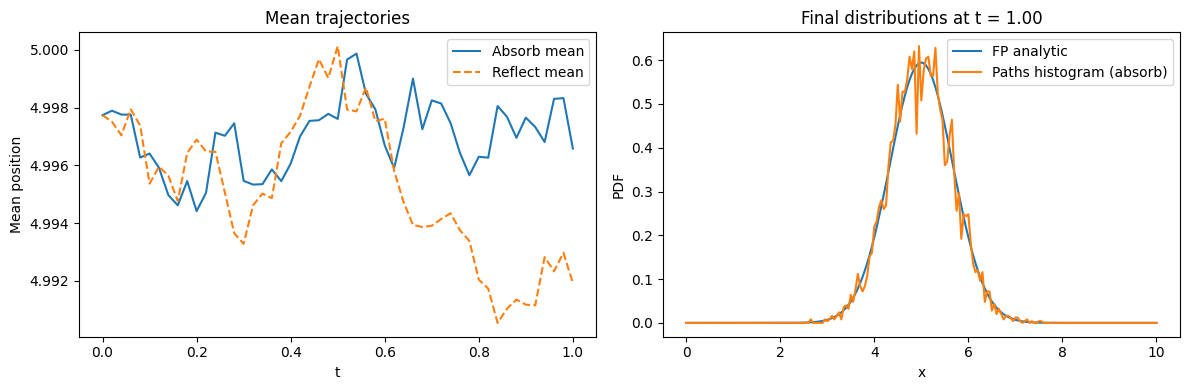

In [29]:
# Plotting: mean trajectories and final distributions

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: mean trajectories
axes[0].plot(t_array, result_absorb['mean'][:, 0], label='Absorb mean')
axes[0].plot(t_array, mean_reflect[:, 0], label='Reflect mean', linestyle='--')
axes[0].set_xlabel('t')
axes[0].set_ylabel('Mean position')
axes[0].legend()
axes[0].set_title('Mean trajectories')

# Right: final distributions
axes[1].plot(x, f_fp, label='FP analytic')
axes[1].plot(x, hist_absorb.flatten(), label='Paths histogram (absorb)')
axes[1].set_xlabel('x')
axes[1].set_ylabel('PDF')
axes[1].legend()
axes[1].set_title('Final distributions at t = {:.2f}'.format(t_array[-1]))

plt.tight_layout()
plt.show()


In [ ]:
# Plot individual paths with threshold check

from stochlib.sde.plotting import plot_paths_with_threshold

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot absorb mode paths (respects alive_mask for boundary absorption)
fig, ax_absorb = plot_paths_with_threshold(
    result_absorb['paths'],
    t_array,
    alive_mask=result_absorb['alive_mask'],
    dim=0,
    max_paths_to_plot=100,
    rng=rng,
    figs_axes=(fig, axes[0]),
    title_suffix="Absorb Mode",
)
ax_absorb.plot(t_array, result_absorb['mean'][:, 0], color='red', linewidth=2, label='Mean')
ax_absorb.legend()

# Plot reflect mode paths (all paths always alive)
fig, ax_reflect = plot_paths_with_threshold(
    result_reflect['paths'],
    t_array,
    alive_mask=None,
    dim=0,
    max_paths_to_plot=100,
    rng=rng,
    figs_axes=(fig, axes[1]),
    title_suffix="Reflect Mode",
)
ax_reflect.plot(t_array, mean_reflect[:, 0], color='red', linewidth=2, label='Mean')
ax_reflect.legend()

plt.tight_layout()
plt.show()
